# Exploratory Data Analysis

The objective of this notebook is to explore customer behavior patterns
and identify factors potentially associated with customer churn.

In [13]:
from src import load_customers

df = load_customers()

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## Overall Churn

Before moving to stratify the churn in different situations, we visualize the total churn preseented in the dataset.

In [14]:
from src import run_sql_file

overall_churn = run_sql_file("overall_churn.sql")

overall_churn

,total_customers,churned_customers,churn_rate
0,7043,1869,26.54


The dataset presents a churn rate of approximately 26.54%, indicating that customer retention may represent a significant business challenge.

---
## Churn by Contract



In [15]:
contract_churn = run_sql_file("churn_by_contract.sql")

contract_churn

,Contract,customers,churn_rate
0,Month-to-month,3875,42.71
1,One year,1473,11.27
2,Two year,1695,2.83


At first glance, customers under longer-term contracts exhibit substantially lower churn rates, especially those under two-year contracts.

However, this relationship may partially reflect a temporal effect. Customers under longer contracts may simply have had fewer opportunities to churn, particularly during the contractual commitment period.

To investigate whether the relationship persists after partially controlling for customer lifetime, we analyze churn rates across different tenure groups.

In [16]:
from src import churn_by_tenure_contract

churn_by_tenure_contract_result = churn_by_tenure_contract(df)

churn_by_tenure_contract_result

,tenure_group,Contract,customers,churn_rate
0,0-11,Month-to-month,1908,51.94
1,0-11,One year,102,7.84
2,0-11,Two year,59,0.00
3,12-23,Month-to-month,765,37.65
4,12-23,One year,199,10.55
5,12-23,Two year,83,0.00
6,24-47,Month-to-month,845,33.61
7,24-47,One year,510,9.80
8,24-47,Two year,269,1.86
9,48+,Month-to-month,357,25.77


Across nearly all tenure groups, customers under longer-term contracts continue
to exhibit lower churn rates relative to month-to-month customers.

This suggests that the observed relationship is not explained solely by
contractual lock-in effects and may indicate stronger long-term customer
retention among customers under annual contracts.

Some particularly relevant observations include:

- 51.94% of customers under month-to-month contracts churn within the first
  11 months;
- No customer currently under a two-year contract churned before reaching
  24 months of tenure.

One important limitation is that the dataset does not contain a temporal
history of contract changes. Therefore, it is not possible to determine
whether customers currently under two-year contracts previously used the
service under shorter contract types before migrating to a longer-term plan.

---
## Churn by Tenure

The previous analysis suggested that customers with longer tenure tend to
present lower churn rates.

To better visualize this relationship, we analyze churn rates across different
tenure values.

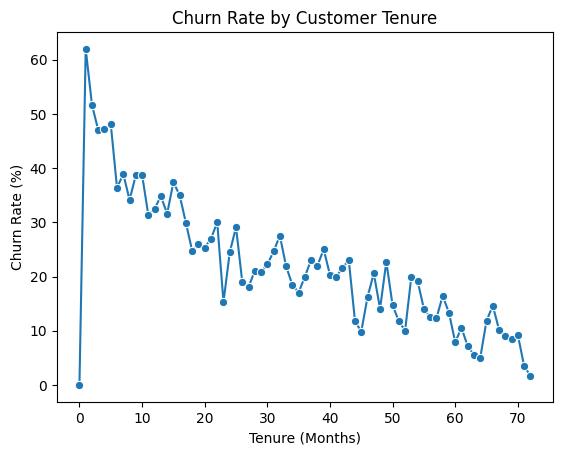

In [17]:
from src import plot_churn_by_tenure

churn_by_tenure = run_sql_file("churn_by_tenure.sql")

plot_churn_by_tenure(churn_by_tenure)

As expected, churn rates generally decrease as tenure increases.

It is important to note, however, that the dataset represents a snapshot of
customers at a single point in time rather than a longitudinal follow-up of
individual customers. Therefore, the results indicate that customers with
higher tenure tend to exhibit lower churn rates, but do not necessarily imply
that churn probability mechanically decreases for a given customer over time.

To provide additional context for the churn curve, we also inspect the
distribution of customers across tenure values.

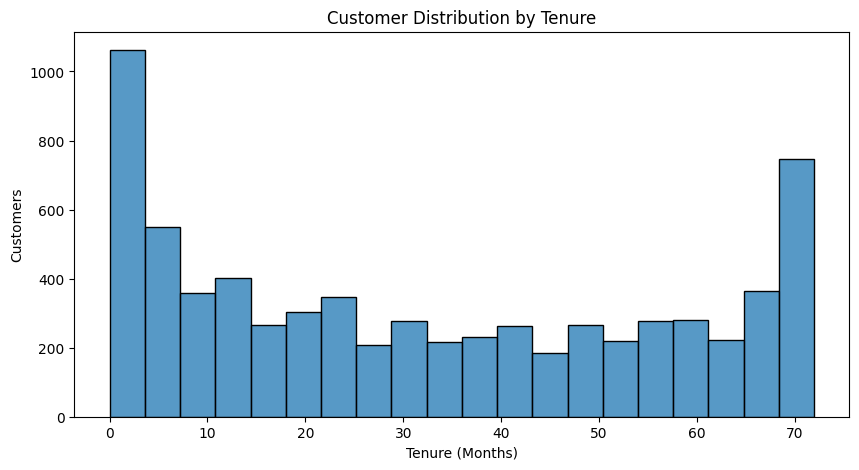

In [18]:
from src import plot_customers_by_tenure

plot_customers_by_tenure(df)

The distribution reveals a strong concentration of customers in the first
months of tenure, followed by a relatively distributed customer base across
intermediate and high tenure values.

A secondary concentration can also be observed among customers with very high
tenure, suggesting the presence of a substantial group of long-term retained
customers.

A particularly sharp decline in churn can be observed during the first months
of the customer lifecycle. To further investigate this pattern, we inspect
customers with tenure between 1 and 6 months.

In [19]:
churn_by_tenure[(churn_by_tenure["tenure"] <= 6) & (churn_by_tenure["tenure"] != 0)]

,tenure,customers,churn_rate
1,1,613,61.99
2,2,238,51.68
3,3,200,47.00
4,4,176,47.16
5,5,133,48.12
6,6,110,36.36


The churn rate falls from 61.99% in the first month to 47.00% by the third
month, representing a decrease of 14.99 percentage points.

By the sixth month, the churn rate reaches 36.36%, corresponding to a total
decrease of 25.63 percentage points relative to the first month. This
represents a relative reduction of approximately 41.35% in churn rate between
the first and sixth months of tenure.

Overall, the results suggest that customers who remain active beyond the
initial months tend to become substantially more stable over time, indicating
that the early stages of the customer lifecycle may be especially important
for retention efforts.

---
## Monthly Charges

We now investigate how churn behaves across different monthly charge levels.

To begin, we inspect the distribution of customers by monthly charges.

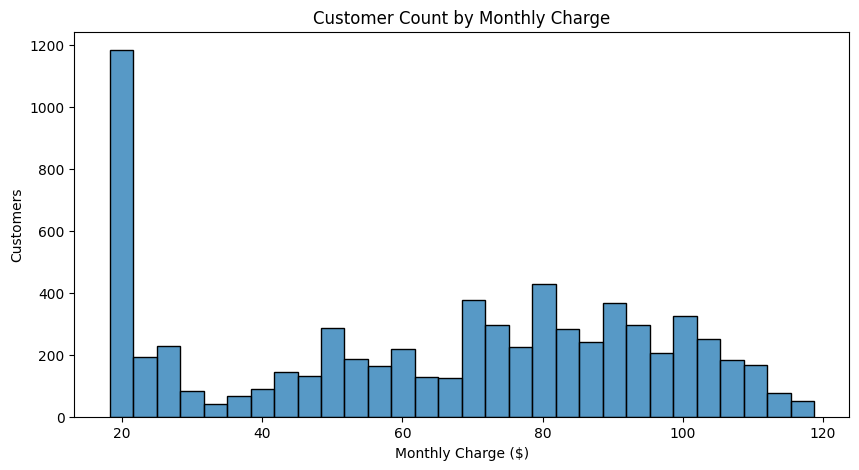

In [20]:
from src import plot_histogram

plot_histogram(df, "MonthlyCharges", bins=30, title="Customer Count by Monthly Charge", xlabel="Monthly Charge ($)", ylabel="Customers")

The distribution reveals a strong concentration of customers around lower
monthly charges, particularly near the $20 range, followed by a broader spread
across intermediate and high charge values.

This pattern suggests the existence of different customer profiles and service
combinations within the dataset.

In [21]:
monthly_charge_churn = run_sql_file("monthly_charges_churn.sql")

monthly_charge_churn

,monthly_charge_group,customers,churn_rate
0,15-24,1389,9.14
1,25-34,342,17.84
2,35-49,563,30.73
3,50-64,845,18.11
4,65-79,1227,36.27
5,80-94,1369,35.65
6,95-109,1089,36.00
7,110+,219,13.70


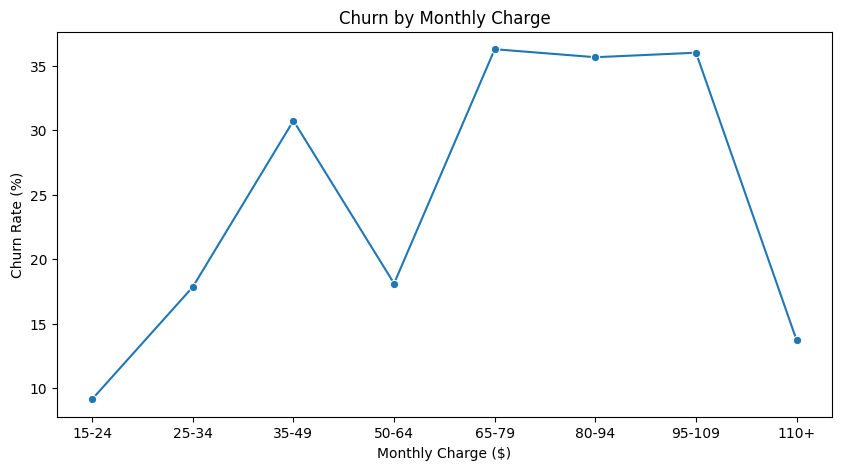

In [22]:
from src import plot_line

plot_line(df=monthly_charge_churn, x="monthly_charge_group", y="churn_rate", title="Churn by Monthly Charge", xlabel="Monthly Charge ($)", ylabel="Churn Rate (%)")


Churn rates generally increase as monthly charges rise, although the relationship is not perfectly monotonic.

Customers in lower charge ranges exhibit substantially lower churn rates,
whereas intermediate and high charge groups tend to present considerably
higher churn levels.

The highest churn rates are concentrated between the 65-79 and 95-109 ranges,
all above 35%.

The decline observed in the 110+ range should be interpreted cautiously, since
this group contains substantially fewer customers relative to the central
ranges of the distribution.

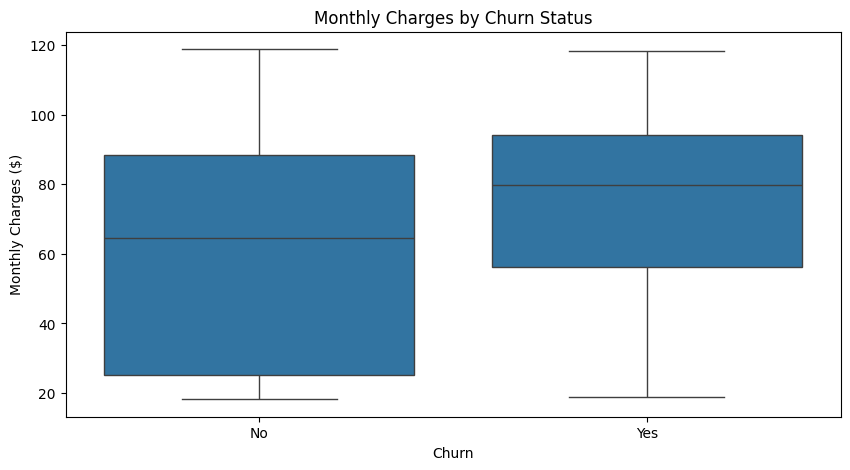

In [23]:
from src import plot_box

plot_box(df=df, x="Churn", y="MonthlyCharges", title="Monthly Charges by Churn Status", xlabel="Churn", ylabel="Monthly Charges ($)")

Customers who churned tend to present higher monthly charges overall.

The median monthly charge among churned customers is noticeably higher than that of retained customers, suggesting that higher-priced customers may be more likely to discontinue the service.

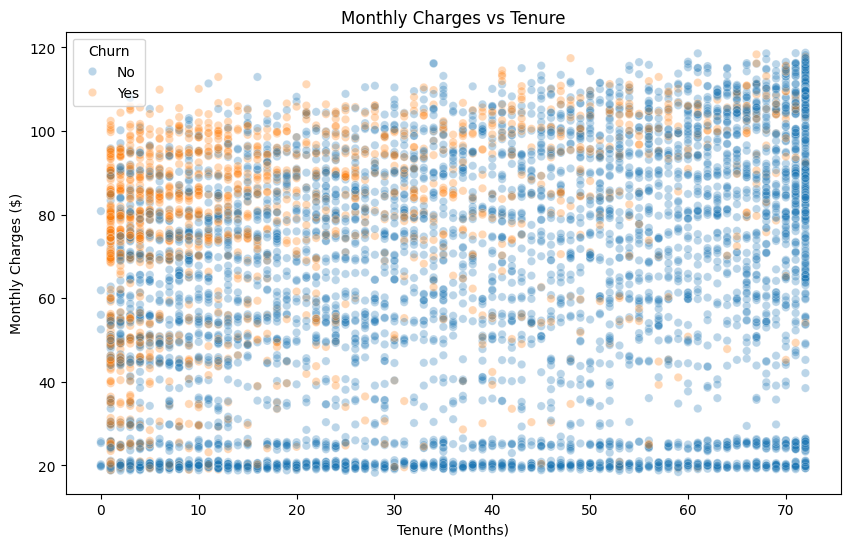

In [24]:
from src import plot_scatter

plot_scatter(df=df, x="tenure", y="MonthlyCharges", hue="Churn", title="Monthly Charges vs Tenure", xlabel="Tenure (Months)", ylabel="Monthly Charges ($)")

The relationship between tenure and monthly charges does not present a clear linear structure. However, churned customers appear to be more concentrated in the region combining low tenure and high monthly charges.

This pattern suggests that customers paying higher prices during the early stages of their lifecycle may be particularly vulnerable to churn.